In [126]:
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import pandas as pd    
import matplotlib.pyplot as plt  
import seaborn as sns
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [127]:
car_mpg = pd.read_csv("cars-dataset.csv")  

In [128]:
car_mpg.head(20)

,car name,cyl,disp,hp,wt,acc,yr,mpg
0,chevrolet chevelle malibu,8,307.0,130,3504,12.0,70,18.0
1,buick skylark 320,8,350.0,165,3693,11.5,70,15.0
2,plymouth satellite,8,318.0,150,3436,11.0,70,18.0
3,amc rebel sst,8,304.0,150,3433,12.0,70,16.0
4,ford torino,8,302.0,140,3449,10.5,70,17.0
5,ford galaxie 500,8,429.0,198,4341,10.0,70,15.0
6,chevrolet impala,8,454.0,220,4354,9.0,70,14.0
7,plymouth fury iii,8,440.0,215,4312,8.5,70,14.0
8,pontiac catalina,8,455.0,225,4425,10.0,70,14.0
9,amc ambassador dpl,8,390.0,190,3850,8.5,70,15.0


In [129]:
car_mpg.shape

(398, 8)

In [130]:
car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null object
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(3), int64(3), object(2)
memory usage: 25.0+ KB


In [131]:
car_mpg.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [132]:
# HP column should be numeric but the data type is object and also it did not show up in describe.

In [133]:
car_mpg["hp"].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [134]:
car_mpg[car_mpg['hp']=='?']
#there are 6 rows with '?' value in hp column

,car name,cyl,disp,hp,wt,acc,yr,mpg
32,ford pinto,4,98.0,?,2046,19.0,71,25.0
126,ford maverick,6,200.0,?,2875,17.0,74,21.0
330,renault lecar deluxe,4,85.0,?,1835,17.3,80,40.9
336,ford mustang cobra,4,140.0,?,2905,14.3,80,23.6
354,renault 18i,4,100.0,?,2320,15.8,81,34.5
374,amc concord dl,4,151.0,?,3035,20.5,82,23.0


In [135]:
#Replacing '?' with median value of 'hp' column
car_mpg["hp"].replace('?',0,inplace=True)
car_mpg["hp"].replace(0,(car_mpg['hp'].median()),inplace=True)

In [136]:
car_mpg[car_mpg['hp']=='?']

,car name,cyl,disp,hp,wt,acc,yr,mpg


In [138]:
car_mpg['hp'] = car_mpg['hp'].astype('float64')

In [139]:
car_mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
car name    398 non-null object
cyl         398 non-null int64
disp        398 non-null float64
hp          398 non-null float64
wt          398 non-null int64
acc         398 non-null float64
yr          398 non-null int64
mpg         398 non-null float64
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [82]:
car_mpg.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
cyl,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
disp,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
hp,398.0,104.281407,38.229470,46.0,76.000,92.0,125.000,230.0
wt,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acc,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
yr,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6


In [140]:
# Dropping Car Name and Manufacturing year columns. I don't think they have any significance. 
car_mpg = car_mpg.drop(['car name','yr'],axis=1)

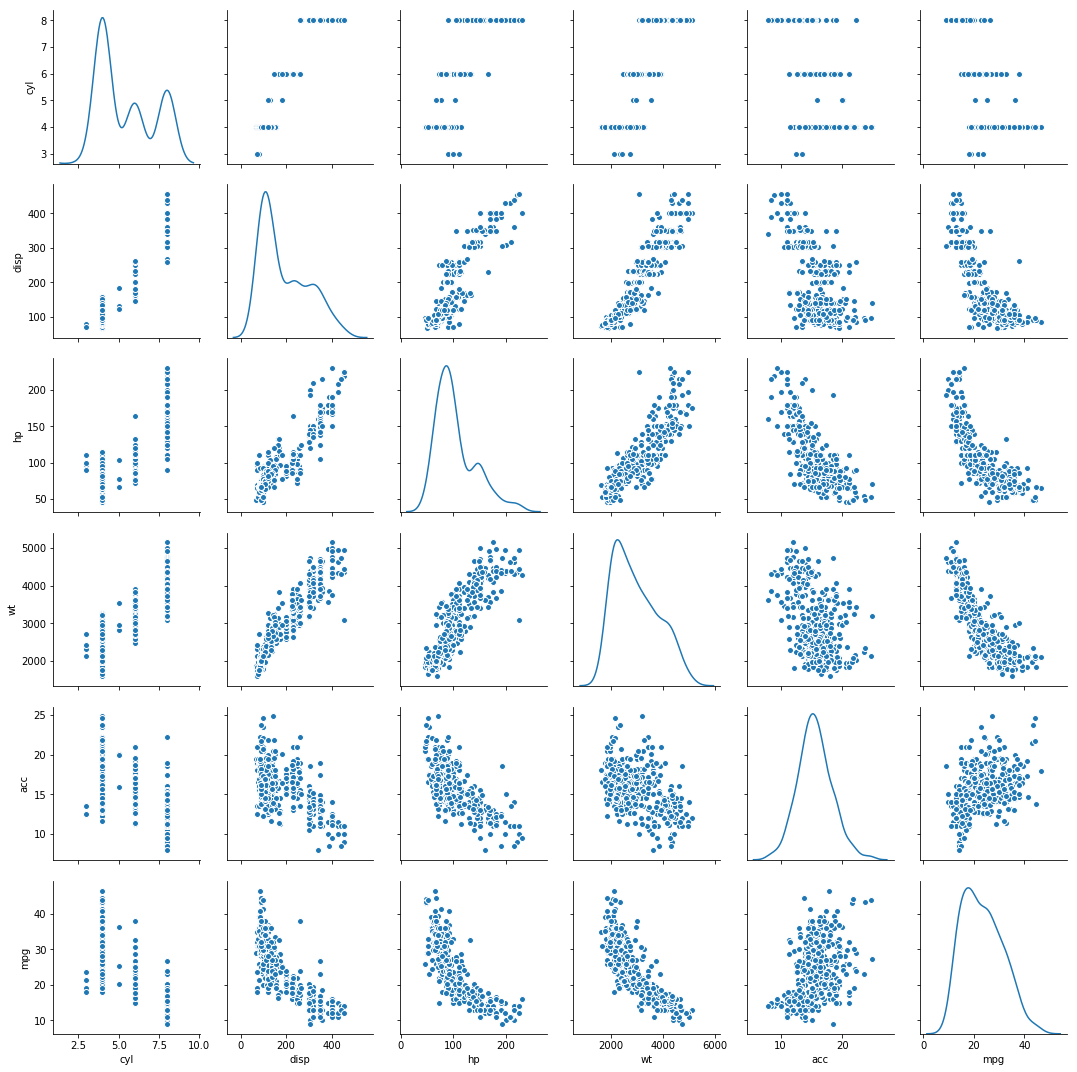

In [141]:
sns.pairplot(car_mpg,diag_kind='kde')

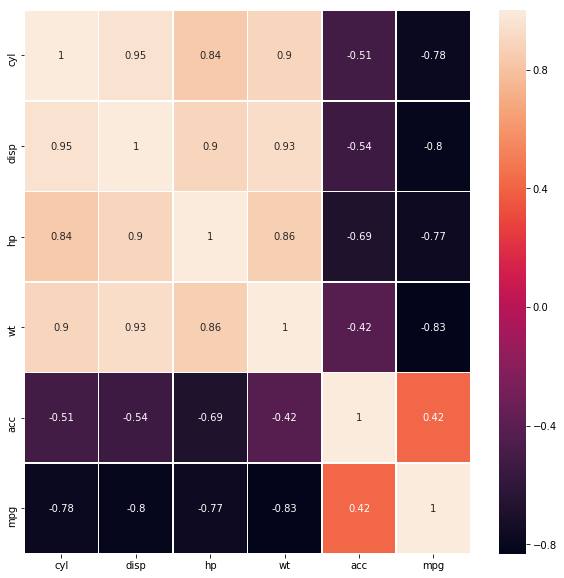

In [85]:
# Check for correlation of variable
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(car_mpg.corr(),annot=True,linewidths=.5, ax=ax)

In [142]:
# Looks like there are 3 clusters. Multi co-linearity exists between independent varriables.

In [146]:
car_mpg_z = car_mpg.apply(zscore)

In [147]:
#Lets check the elbow plot to get optimal value for number of clusters.
cluster_range = range( 2, 6)
cluster_errors = []
for num_clusters in cluster_range:
  clusters = KMeans( num_clusters, n_init = 5)
  clusters.fit(car_mpg)
  labels = clusters.labels_
  centroids = clusters.cluster_centers_
  cluster_errors.append( clusters.inertia_ )
clusters_df = pd.DataFrame( { "num_clusters":cluster_range, "cluster_errors": cluster_errors } )

In [148]:
clusters_df

,num_clusters,cluster_errors
0,2,7.429388e+07
1,3,3.420301e+07
2,4,1.905173e+07
3,5,1.376469e+07


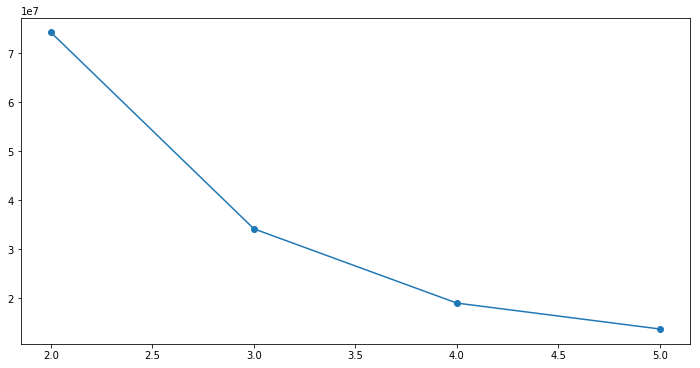

In [149]:
plt.figure(figsize=(12,6))
plt.plot( clusters_df.num_clusters, clusters_df.cluster_errors, marker = "o" )

For n_clusters = 3 The average silhouette_score is : 0.5860768948179083


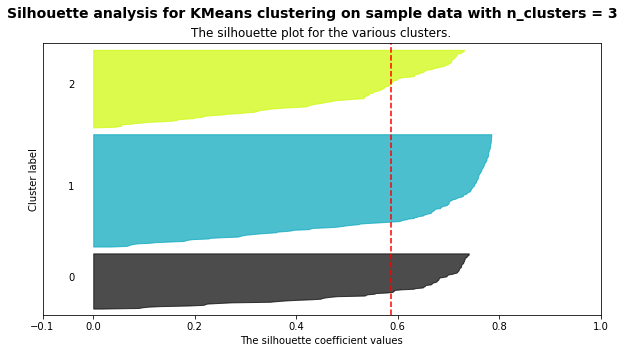

For n_clusters = 4 The average silhouette_score is : 0.5793615028175053


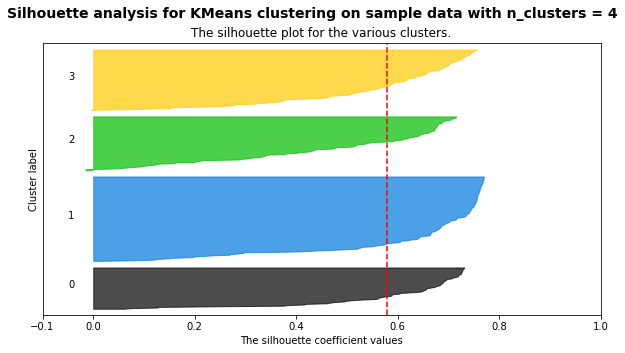

In [150]:
# From the elbow plot looks like number of cluster = 4
# Lets check the Shilhoute coefficient for number of clusters = 3 and 4
range_n_clusters = [3, 4]

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1) = plt.subplots(1)
    fig.set_size_inches(10, 5)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(car_mpg) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(car_mpg)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(car_mpg, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(car_mpg, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    #colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    #ax2.scatter(car_mpg[:, 0], car_mpg[:, 1], marker='.', s=30, lw=0, alpha=0.7,
    #            c=colors)

    # Labeling the clusters
    #centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
   # ax2.scatter(centers[:, 0], centers[:, 1],
   #             marker='o', c="white", alpha=1, s=200)

    #for i, c in enumerate(centers):
    #    ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1, s=50)

    #ax2.set_title("The visualization of the clustered data.")
    #ax2.set_xlabel("Feature space for the 1st feature")
    #ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(("Silhouette analysis for KMeans clustering on sample data "
                  "with n_clusters = %d" % n_clusters),
                 fontsize=14, fontweight='bold')

    plt.show()

In [ ]:
# number of cluster = 3 and 4 have almost same coefficent but 4 shows good clusters. 
# We will take number of clusters = 4

In [151]:
kmeans= KMeans(n_clusters=4,random_state=10)
prediction = kmeans.fit_predict(car_mpg_z)

In [152]:
car_mpg_z["GROUP"] = prediction 
car_mpg_z.head()

,cyl,disp,hp,wt,acc,mpg,GROUP
0,1.498191,1.090604,0.673589,0.630870,-1.295498,-0.706439,3
1,1.498191,1.503514,1.590266,0.854333,-1.477038,-1.090751,3
2,1.498191,1.196232,1.197404,0.550470,-1.658577,-0.706439,3
3,1.498191,1.061796,1.197404,0.546923,-1.295498,-0.962647,3
4,1.498191,1.042591,0.935497,0.565841,-1.840117,-0.834543,3


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


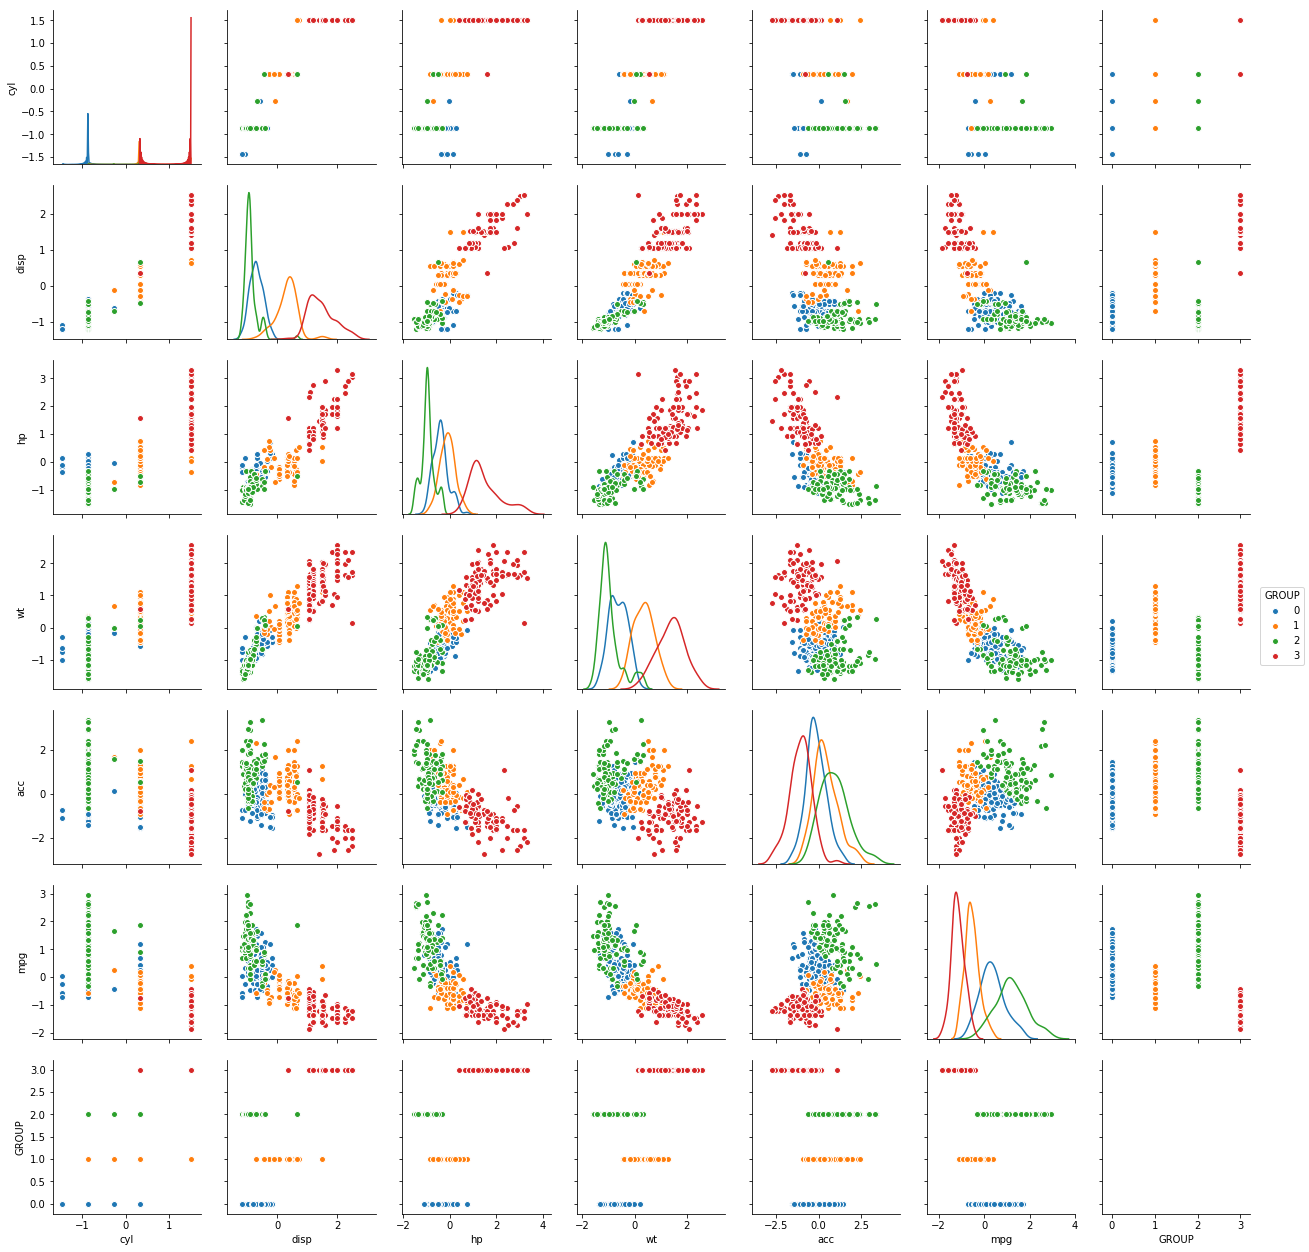

In [153]:
sns.pairplot(car_mpg_z,diag_kind='kde', hue='GROUP') 

In [154]:
car_mpg_z.groupby(['GROUP']).count()['mpg']

GROUP
0    125
1     84
2     92
3     97
Name: mpg, dtype: int64

In [155]:
#Separating each group and applying linear regression to each cluster
cls0 = pd.DataFrame(car_mpg_z[car_mpg_z['GROUP'] == 0]) 
cls1 = pd.DataFrame(car_mpg_z[car_mpg_z['GROUP'] == 1]) 
cls2 = pd.DataFrame(car_mpg_z[car_mpg_z['GROUP'] == 2]) 
cls3 = pd.DataFrame(car_mpg_z[car_mpg_z['GROUP'] == 3]) 

In [156]:
cls_list=[cls0,cls1,cls2,cls3] 

cls_ln_result=pd.DataFrame() 

for cls_num in cls_list:
    X = cls_num.drop(['mpg','GROUP'],axis=1)
    Y = cls_num['mpg']
    test_size = 0.3
    seed = 4
    X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)
    model = LinearRegression()
    model.fit(X_train, Y_train)
    Y_predict_train = model.predict(X_train)
    Y_predict_test = model.predict(X_test)
    mse_train = metrics.mean_squared_error(Y_predict_train, Y_train)
    trainRmse = np.sqrt(mse_train)
    mse_test = metrics.mean_squared_error(Y_predict_test, Y_test)
    testRmse = np.sqrt(mse_test)
    cls_ln_result = cls_ln_result.append({'Train RMSE': trainRmse, 'Test RMSE': testRmse,'Intercept': model.intercept_, 'Coefficient': np.around(model.coef_,4)}, ignore_index=True)
    


In [157]:
cls_ln_result

,Coefficient,Intercept,Test RMSE,Train RMSE
0,"[0.1518, 0.6672, -0.6812, -0.4971, -0.2813]",0.354742,0.409257,0.437346
1,"[0.3018, -0.2727, -0.0466, -0.299, 0.0313]",-0.455497,0.315499,0.280712
2,"[0.3121, -2.7905, -0.5658, 0.8618, -0.4497]",-0.431230,0.979983,0.577045
3,"[-0.2981, 0.0696, -0.1604, -0.2193, -0.0578]",-0.341715,0.207634,0.220302
